# Data Analysis Report 

## Introduction  
The dataset provided contains player-level statistics from PUBG matches. The main goal is to predict the winning percentage (`winPlacePerc`) of a player or team in a match. Before building models, it is important to understand the dataset structure and the type of information it provides.  

## Dataset Overview  
- **Number of columns:** 29  
- **Target variable:** `winPlacePerc` (ranges between 0 and 1)  
- **Data type:** Combination of numeric and categorical features  

### Column Categories
- **Identifiers:** `Id`, `groupId`, `matchId`  
- **Player performance stats:** `kills`, `damageDealt`, `headshotKills`, `assists`, `DBNOs`, `killStreaks`  
- **Movement stats:** `walkDistance`, `rideDistance`, `swimDistance`  
- **Support stats:** `heals`, `revives`, `boosts`  
- **Game information:** `matchType`, `matchDuration`, `maxPlace`  
- **Scoring features:** `killPoints`, `rankPoints`, `winPoints`  

## Data Characteristics  
- Each row in the dataset represents an **individual player’s performance in a match**.  
- The identifiers (`Id`, `groupId`, `matchId`) are unique and help in grouping players into teams and matches.  
- The dataset contains both **continuous features** (e.g., `walkDistance`, `damageDealt`) and **discrete/categorical features** (e.g., `matchType`).  
- Features like `walkDistance`, `kills`, and `damageDealt` provide direct measures of player activity and performance.  
- Features like `revives`, `assists`, and `boosts` capture teamwork and survival strategy.  
- The target variable `winPlacePerc` acts as a performance score, with **0 indicating the lowest placement** and **1 indicating the winner of the match**.  

## Key Takeaway  
The dataset is rich in gameplay-related features, covering **combat, movement, survival, and match-level context**. These factors together will help in understanding and predicting a player’s chance of winning. 

## Importing Necessary Libraries

In [10]:
# Importing required libraries/modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Suppressing warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset 

In [11]:
data = pd.read_csv("pubg.csv") # Loading dataset from CSV into a pandas DataFrame

## Basic Check 

In [12]:
data.head() # Showing first few rows for a quick glance at structure

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,1241,0,0,0.00,1306,squad-fpp,28,26,-1,0,0.00,0,0.00,0,0,244.80,1,1466,0.44
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,0,0,0,0.00,1777,squad-fpp,26,25,1484,0,0.00,0,11.04,0,0,1434.00,5,0,0.64
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,0,0,0,0.00,1318,duo,50,47,1491,0,0.00,0,0.00,0,0,161.80,2,0,0.78
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,0,0,0,0.00,1436,squad-fpp,31,30,1408,0,0.00,0,0.00,0,0,202.70,3,0,0.17
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,0,1,1,58.53,1424,solo-fpp,97,95,1560,0,0.00,0,0.00,0,0,49.75,2,0,0.19


In [13]:
data.info()  # Inspecting dtypes and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints   

In [14]:
data.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

In [15]:
# Format floats to 2 decimal places for cleaner tables
pd.set_option('display.float_format', '{:.2f}'.format)

# Ensure all columns are displayed in the summary (no truncation)
pd.set_option('display.max_columns', None)

# Generate descriptive statistics for numerical features
data.describe() 

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,maxPlace,numGroups,rankPoints,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446966.00,4446965.00
mean,0.23,1.11,130.72,0.66,0.23,1.37,47.60,505.01,0.92,0.54,23.00,1579.51,44.50,43.01,892.01,0.16,606.12,0.00,4.51,0.02,0.01,1154.22,3.66,606.46,0.47
std,0.59,1.72,170.78,1.15,0.60,2.68,27.46,627.50,1.56,0.71,50.97,258.74,23.83,23.29,736.65,0.47,1498.34,0.07,30.50,0.17,0.09,1183.50,2.46,739.70,0.31
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,9.00,1.00,1.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,24.00,0.00,0.00,0.00,0.00,1367.00,28.00,27.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,155.10,2.00,0.00,0.20
50%,0.00,0.00,84.24,0.00,0.00,0.00,47.00,0.00,0.00,0.00,0.00,1438.00,30.00,30.00,1443.00,0.00,0.00,0.00,0.00,0.00,0.00,685.60,3.00,0.00,0.46
75%,0.00,2.00,186.00,1.00,0.00,2.00,71.00,1172.00,1.00,1.00,21.32,1851.00,49.00,47.00,1500.00,0.00,0.19,0.00,0.00,0.00,0.00,1976.00,5.00,1495.00,0.74
max,22.00,33.00,6616.00,53.00,64.00,80.00,101.00,2170.00,72.00,20.00,1094.00,2237.00,100.00,100.00,5910.00,39.00,40710.00,18.00,3823.00,12.00,5.00,25780.00,236.00,2013.00,1.00


### Insights

### Player performance and kills
- **Assists, DBNOs, Headshot Kills, Kills**  
  - Median = 0 → Most players don’t get assists, DBNOs, or headshots in a match.  
  - Maximum values are very high (72 kills, 64 headshots, 22 assists) → but these are rare outliers.  
  - Mean values are all less than 1 → confirms that players usually manage only a small number of kills.  

- **Kill Streaks**  
  - Median = 0, 75% also = 1 → most players don’t get kill streaks.  
  - Maximum streak = 20 → rare extreme case.  

### Healing and boosts
- **Heals**  
  - Median = 0, Mean ≈ 1.3 → most players do not use heals much, often because they die early.  

- **Boosts**  
  - Median between 1–2 → some usage, but not too frequent.  

### Damage
- **Damage Dealt**  
  - Median ≈ 84 → half the players deal less than 100 damage, which is very low.  
  - Mean ≈ 130, Max ≈ 66,000 → a few extreme outliers skew the distribution.  

### Movement
- **Walk Distance**  
  - Median ≈ 685, Mean ≈ 1154 → most players cover less than 1 km.  
  - Max = 25,780 → extreme outlier values.  

- **Ride Distance**  
  - Median = 0 → most players never use vehicles.  
  - Mean ≈ 606, but Max = 407,000 → clear evidence of outliers or glitches.  

- **Swim Distance**  
  - Median = 0, 75% = 0 → swimming is almost never used.  
  - Max = 3,823 → rare extreme cases.  

### Vehicles
- **Vehicle Destroys**  
  - Median = 0, Mean ≈ 0.01 → almost nobody destroys vehicles.  

- **Road Kills**  
  - Median = 0, Max = 18 → very rare events.  

### Weapons
- **Weapons Acquired**  
  - Median = 3, Mean ≈ 3.6 → most players pick up 2–4 weapons.  
  - Max = 236 → extreme outlier.  

### Match outcomes
- **Kill Place**  
  - Median ≈ 47 → many players end up in middle placements.  

- **Win Place Percent**  
  - Median ≈ 0.46 → average placement is around the middle.  
  - Values range from 0 to 1 (worst to best).  

- **Win Points & Kill Points**  
  - Many values are 0 → these scoring systems are outdated and not reliable for modern analysis.  

### Match duration and groups
- **Match Duration**  
  - Median ≈ 1438 seconds (~24 minutes) → typical game lasts around 20–25 minutes.  
  - Max = 2237 seconds (~37 minutes).  

- **NumGroups**  
  - Median ≈ 30 → on average there are 30 teams per match.  
  - Max = 100 → corresponds to solo matches.

In [16]:
data.describe(include = "O") # Getting summary statistics to understand categorical distributions 

,Id,groupId,matchId,matchType
count,4446966,4446966,4446966,4446966
unique,4446966,2026745,47965,16
top,7f96b2f878858a,14d6b54cdec6bc,4b5db40aec4797,squad-fpp
freq,1,74,100,1756186


### Insights

### Id  
- All 4,446,966 rows have unique Id values.  
- Each Id appears only once → this is simply a unique identifier column.  

### groupId  
- Around 2,026,745 unique group IDs.  
- The most frequent groupId occurs 74 times → meaning some groups appear across multiple matches.  

### matchId  
- Around 47,965 unique matches in the dataset.  
- The most frequent matchId occurs 100 times → this indicates that match records are split across players within the same match.  

### matchType  
- 16 unique match types.  
- The most common type is **squad-fpp**, with about 1.75 million records.  
- This shows that squad matches in first-person perspective are the dominant mode in the dataset.

## Exploratory Data Analysis(EDA) 

### Univariate Analysis 

#### 1. For Continuous Columns: 

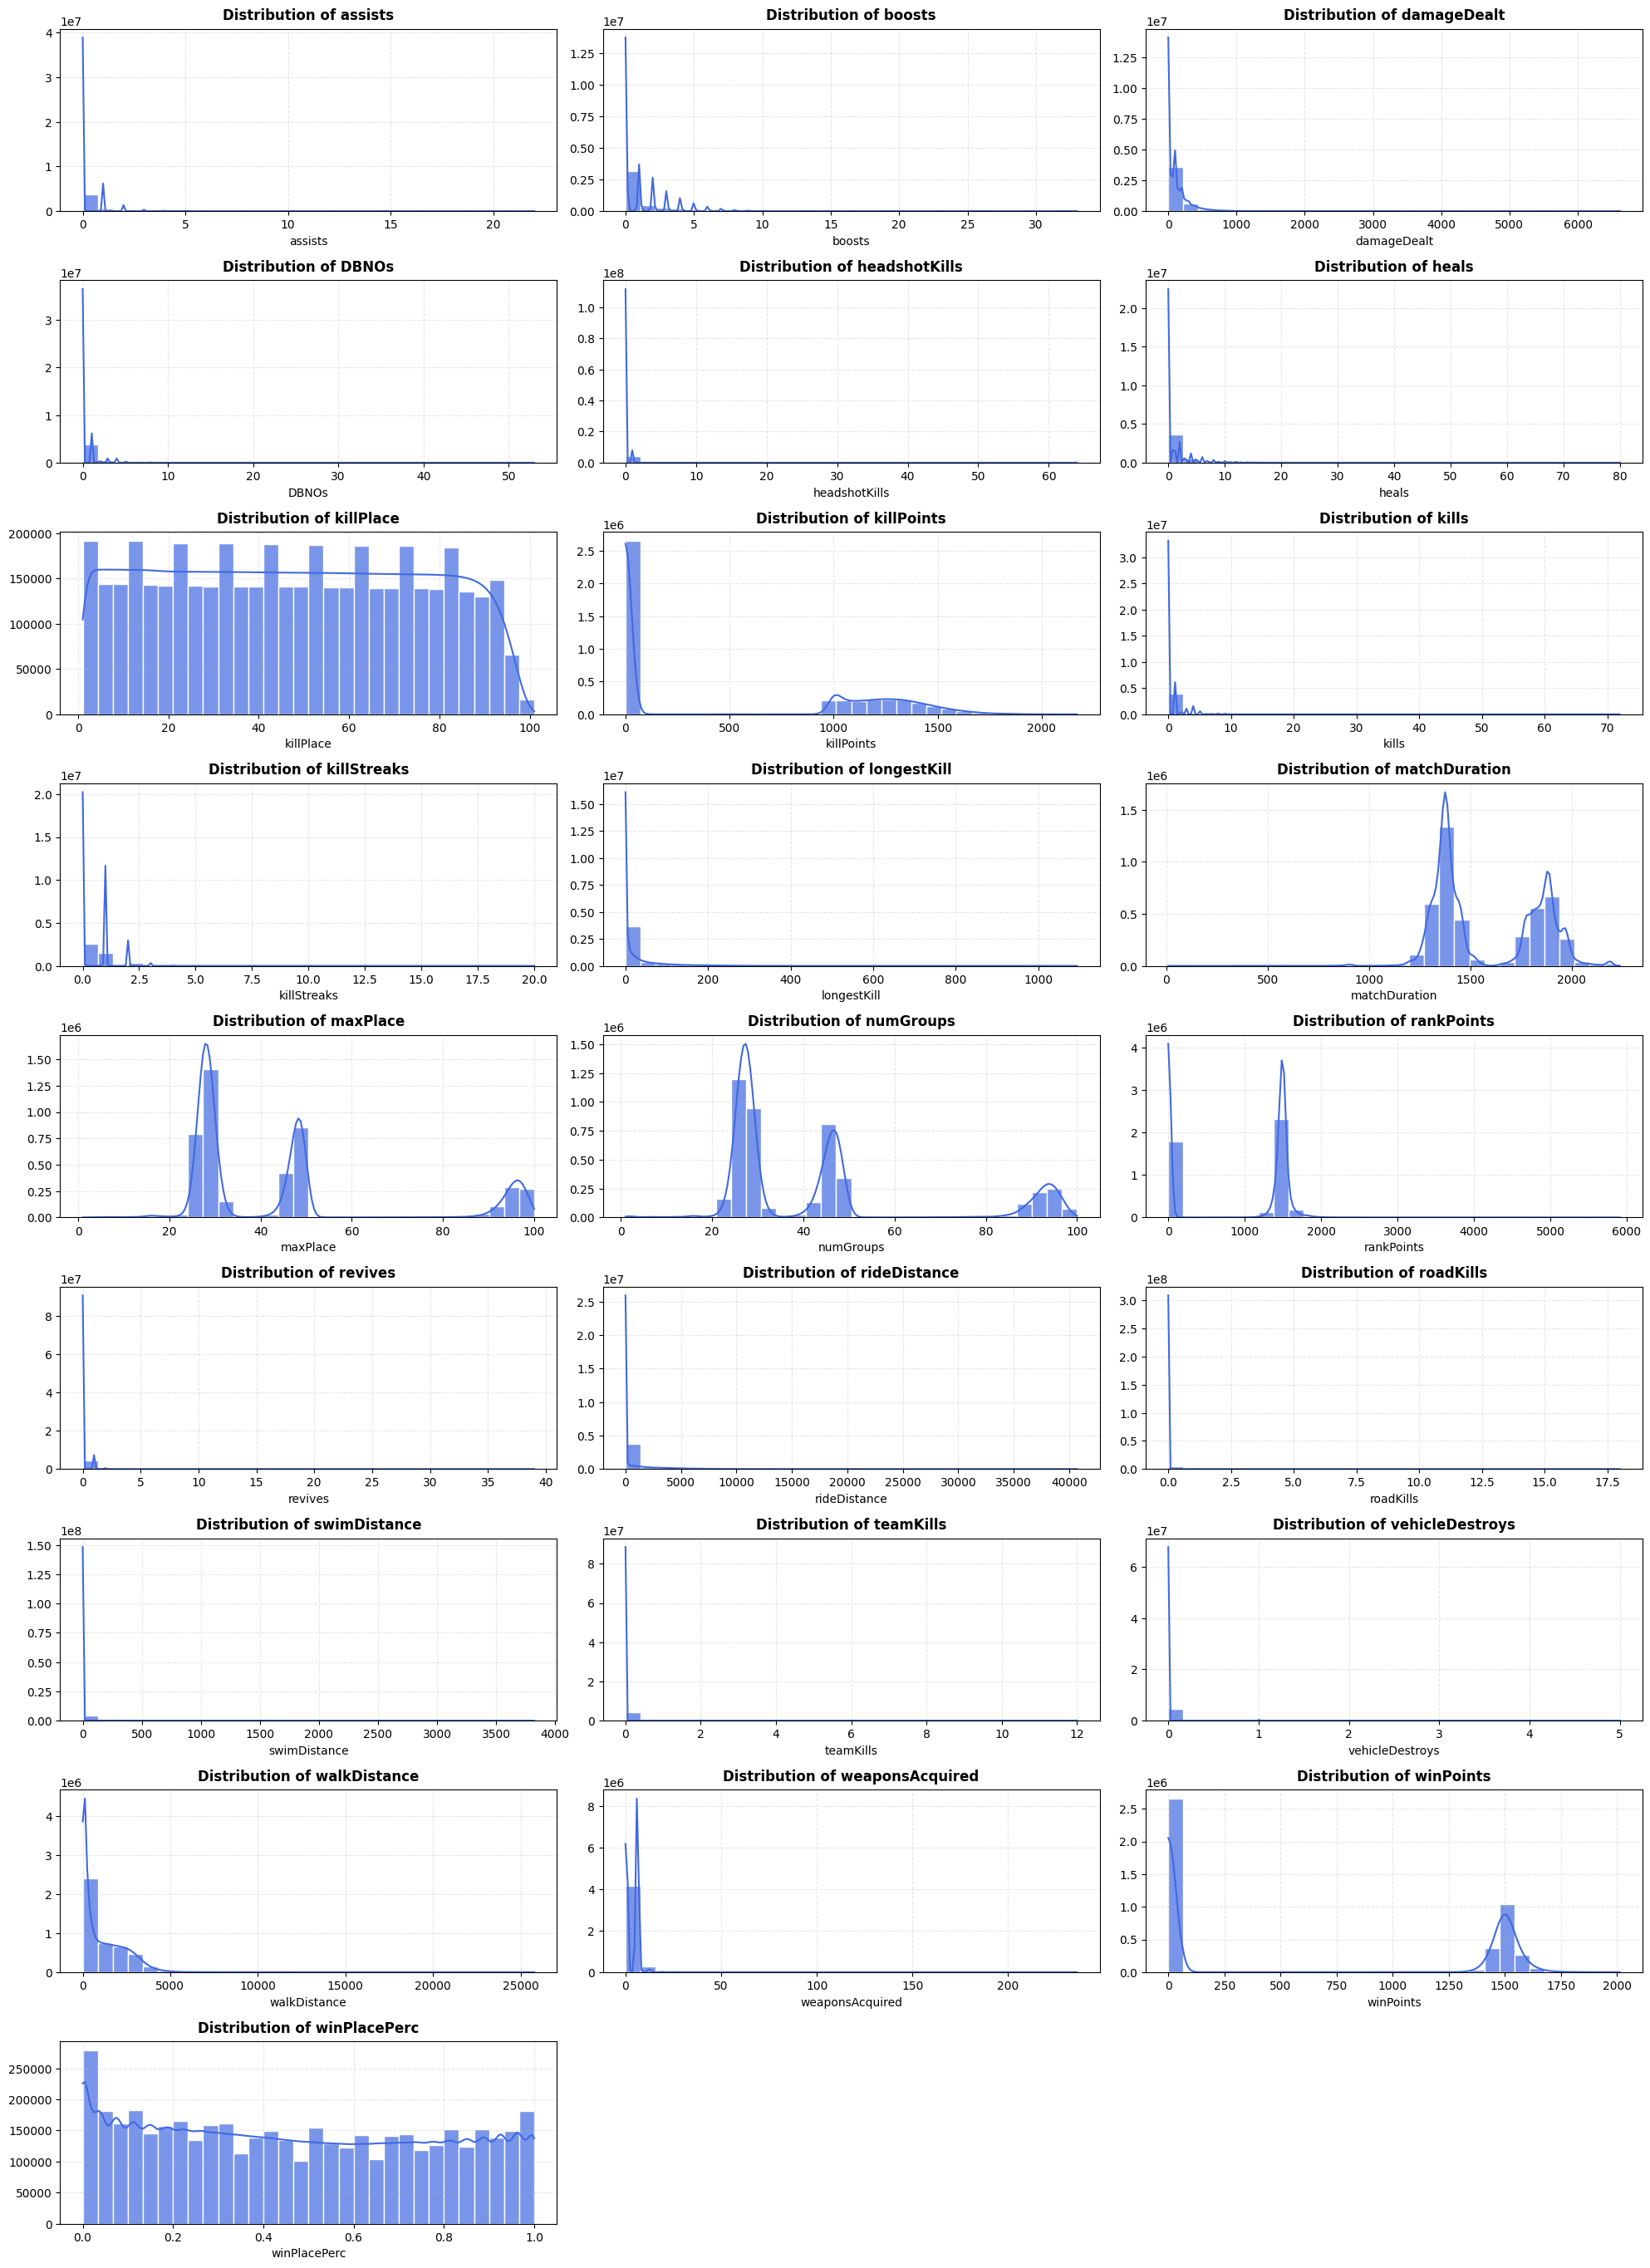

In [8]:
plt.figure(figsize=(20, 30))  # large canvas to fit many plots clearly

# Select only numeric columns for distribution analysis
numerical_cols = data.select_dtypes(include=["int", "float"])

# Loop through each numeric column and plot its distribution
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(10, 3, i)   # arrange plots in a grid (10 rows x 3 cols)

    # Histogram with KDE overlay to see both frequency and smooth density
    sns.histplot(
        data[col],
        kde=True,
        bins=30,
        color="royalblue",       # consistent soft blue for readability
        edgecolor="white",       # white borders keep bars separate
        alpha=0.7                # slight transparency for a cleaner look
    )

    plt.title(f"Distribution of {col}", fontsize=12, fontweight="bold", pad=8)
    plt.ylabel("")              # remove y-axis label to reduce clutter
    plt.grid(True, linestyle="--", alpha=0.3)   # subtle grid for guidance

# Adjust spacing so titles and plots don’t overlap
plt.tight_layout()
plt.show()

#### Univariate Insights(Continuous)

### Player performance (kills, assists, DBNOs, headshots, streaks)
- Most players have **0 assists, DBNOs, headshot kills, and kill streaks**.  
- The majority of players also have **0 kills**, confirming that only a small percentage of players score kills in a given match.  
- Extreme values (like 70+ kills or 20+ kill streaks) exist but are **rare outliers**.  

### Damage and healing
- **Damage Dealt** is highly right-skewed: most players deal less than 500 damage.  
- A small number of players deal very high damage (above 5000), which skews the distribution.  
- **Heals and Boosts** are concentrated at low values (mostly 0–2). This means most players either die early or do not use many healing items.  

### Placement and ranking
- **Kill Place** is uniformly distributed between 1 and 100, meaning players are spread across different rankings.  
- **Win Place Percent** is more balanced, with many players around the mid-range, but it covers the entire 0 to 1 scale.  

### Movement
- **Walk Distance**: most players travel less than 2000 meters. A few extreme cases exceed 20,000 meters.  
- **Ride Distance**: most players do not use vehicles at all (peak at 0). A few extreme cases show very high values, likely due to outliers or glitches.  
- **Swim Distance**: almost always 0, confirming swimming is rarely used.  

### Vehicles
- **Vehicle Destroys** and **Road Kills**: almost always 0, very rare events.  
- This shows vehicle-based actions are uncommon compared to shooting or walking.  

### Weapons
- **Weapons Acquired**: most players pick up around 2–4 weapons.  
- A few extreme outliers have more than 200 weapons, which is unrealistic and likely due to abnormal matches.  

### Match details
- **Match Duration**: centered around 20–25 minutes, but some matches last longer.  
- **NumGroups**: commonly around 25–30, with peaks at 50 and 100 (corresponding to different match formats like squads vs solos).  

### Points
- **Kill Points, Win Points, Rank Points**: heavily skewed with many zeros.  
- These scoring columns are not very reliable, since PUBG updated its ranking system.

#### 2. For Categorical Columns: 

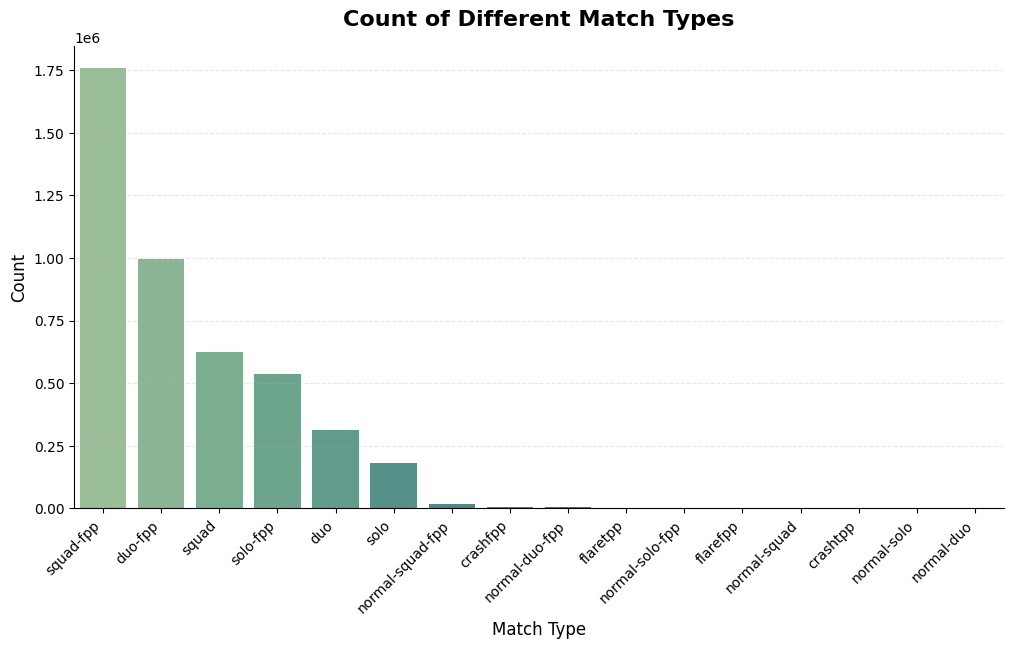

In [9]:
plt.figure(figsize=(12, 6))

# Countplot of match types, ordered by frequency
sns.countplot(
    x="matchType",
    data=data,
    palette="crest",                          # soft, consistent color palette
    order=data["matchType"].value_counts().index  # sort bars from most to least common
)

# Titles and axis labels
plt.title("Count of Different Match Types", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Match Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha="right")

# Horizontal gridlines for easier comparison
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()   # cleaner style
plt.show()

#### Univariate Insights(Categorical – Match Type)
- There are 16 match types in the dataset.  
- The most common mode is **squad-fpp**, followed by duo-fpp and squad (TPP).  
- Less common modes include solo, duo, and event modes like flare-fpp and crashfpp.  
- This shows the dataset is **dominated by squad matches in first-person perspective**.

### Bivariate Analysis

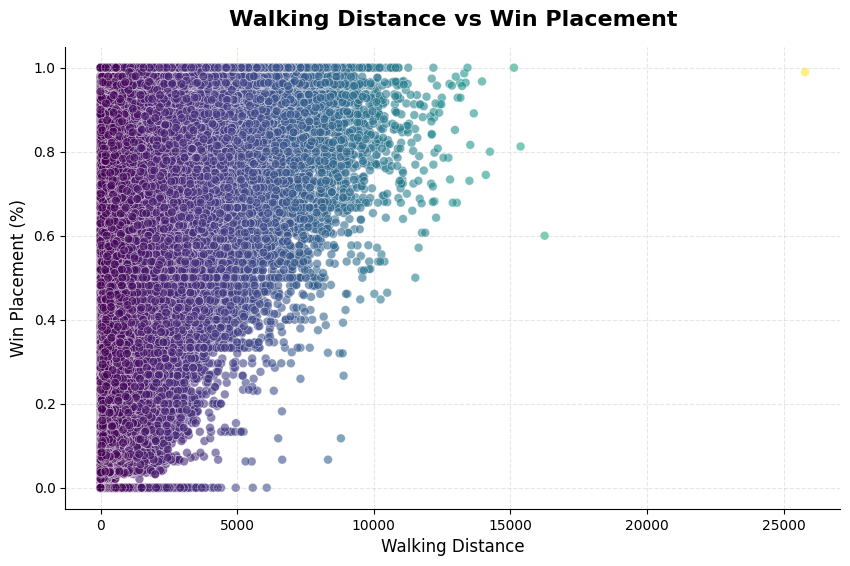

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="walkDistance",
    y="winPlacePerc",
    data=data,
    alpha=0.6,                     # makes overlapping points easier to see
    edgecolor="white",             # gives points a neat separation
    s=40,
    linewidth=0.4,
    palette="viridis",             # gradient colors for a smooth, professional look
    hue="walkDistance",            # color shows walking distance intensity
    legend=False                   # legend not useful here since hue is continuous
)

# Title and labels to clearly describe the plot
plt.title("Walking Distance vs Win Placement", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Walking Distance", fontsize=12)
plt.ylabel("Win Placement (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)   # light grid for readability
sns.despine()                               # cleaner style by removing extra borders

plt.show()

#### Walk Distance vs Winning Probability

- **Positive Correlation:**
  There is a clear positive correlation between **walk distance** and the **winning probability** of a player. Players who walk more usually survive longer and therefore have higher chances of winning.

- **Important Note:**
  Walking more does not directly cause wins. Instead, it acts as an **indicator** — skilled players survive longer, move across zones, loot, and engage in fights, which naturally increases both walk distance and winning probability.

- **Cluster Observation (0–4000 distance):**
  A group of players shows nearly ~1 winning probability even with relatively low walk distance. These could be exceptional cases like:
  - Being carried by teammates
  - Early eliminations
  - Possible AFK players or dataset quirks

- **Conclusion:**
  Walk distance is a strong signal of **survival and performance**. For deeper insights, it should also be compared with other distance-related features such as **rideDistance** and **swimDistance**. 

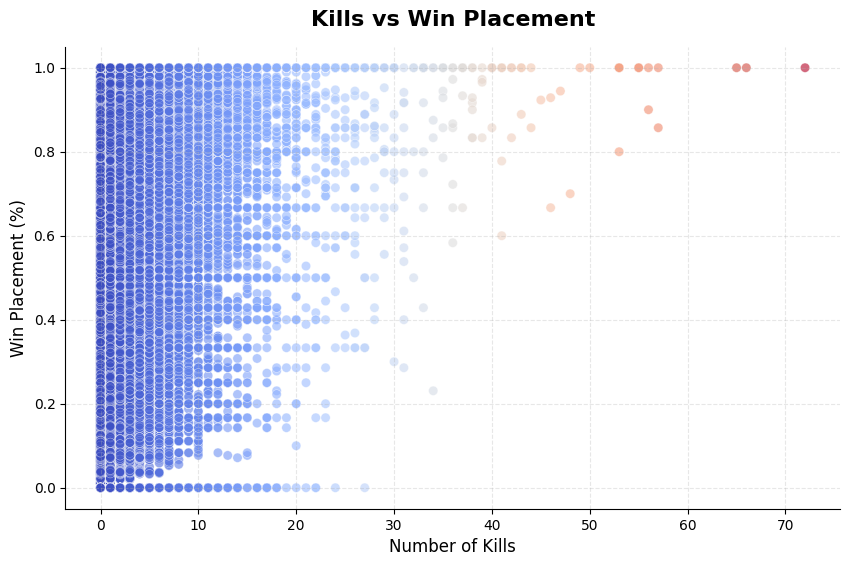

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="kills",
    y="winPlacePerc",
    data=data,
    alpha=0.6,                     # a bit transparent so dense areas don’t look messy
    edgecolor="white",             # thin outline helps separate overlapping points
    s=45,                          # balanced marker size for visibility
    linewidth=0.4,
    hue="kills",                   # color reflects number of kills (gives extra layer of info)
    palette="coolwarm",            # contrasting colors highlight low vs high kills
    legend=False                   # legend not needed since hue is continuous
)

# Add descriptive title and axis labels
plt.title("Kills vs Win Placement", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Number of Kills", fontsize=12)
plt.ylabel("Win Placement (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)   # light dashed grid for easier reading
sns.despine()                               # remove top/right borders for a cleaner style

plt.show()

Kills show a positive correlation with winning probability, but the relationship is not as strong as with walk distance.

- For players with around **0–5 kills**, the winning probability is spread across all ranges. This means that having a few kills does not necessarily guarantee a higher chance of winning.
- Once players achieve **more than 30 kills**, the chances of winning are almost always higher. However, these cases are extremely rare and may even represent anomalies or outliers in the dataset.
- Unlike walk distance (which accumulates naturally as players survive), kills depend heavily on aggressive gameplay and player skill, so the correlation with winning is less consistent.

**Conclusion:** Kills are an important indicator of performance, but on their own they are not a strong standalone predictor of winning compared to movement-based features.

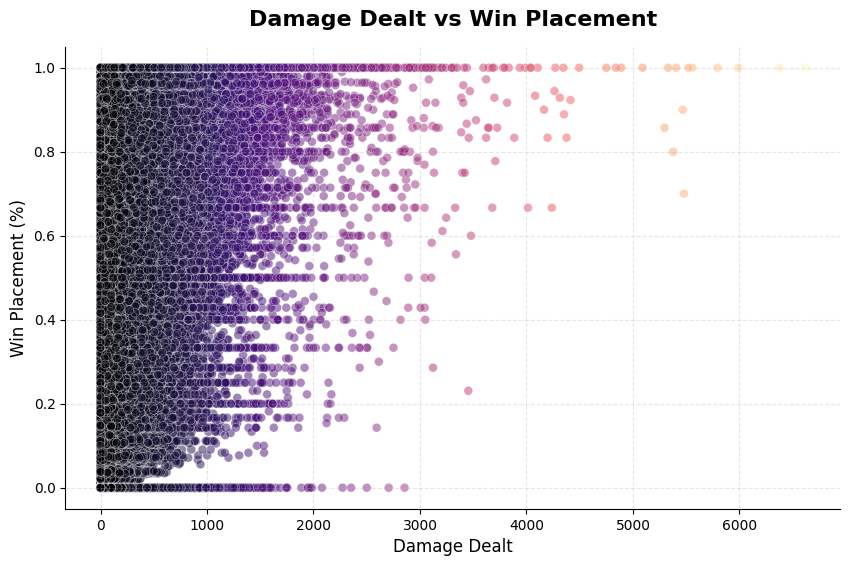

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="damageDealt",
    y="winPlacePerc",
    data=data,
    alpha=0.5,                     # transparency helps when many points overlap
    edgecolor="white",             # thin outline makes points stand out clearly
    s=40,
    linewidth=0.4,
    hue="damageDealt",             # color gradient shows intensity of damage dealt
    palette="magma",               # dark-to-bright scheme highlights low vs high values
    legend=False                   # legend unnecessary since hue is continuous
)

# Clear and descriptive title + labels
plt.title("Damage Dealt vs Win Placement", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Damage Dealt", fontsize=12)
plt.ylabel("Win Placement (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)   # subtle grid to guide the eye
sns.despine()                               # removes extra borders for a clean look

plt.show()

Damage dealt shows a positive relationship with winning probability, but the correlation is weaker compared to features like walk distance.

- At around **0–500 damage**, some players still have a winning probability close to 1. These may represent players who survive longer with little combat involvement, or those carried by their teammates.
- Overall, the spread is wide, meaning that dealing some damage does not necessarily guarantee higher winning chances. A player can deal damage without securing kills, so the effect is less consistent.
- Once damage exceeds **3000**, the chances of winning are much higher. However, such cases are rare, and extreme values above 4000–6000 may represent outliers or unusual matches.

**Conclusion:** Damage dealt is a useful indicator of engagement and survival, but on its own it is not a strong standalone predictor of winning.

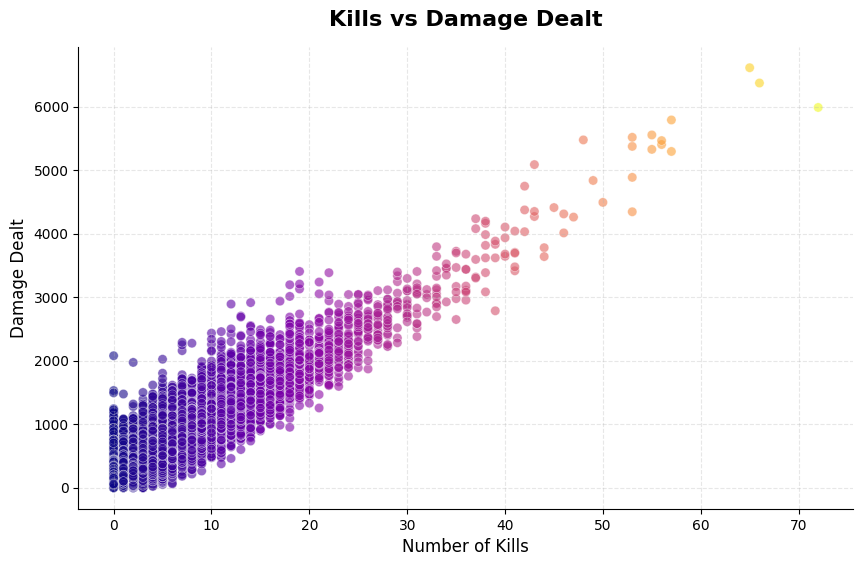

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="kills",
    y="damageDealt",
    data=data,
    alpha=0.6,                     # slight transparency helps when points overlap
    edgecolor="white",             # thin outline keeps markers distinct
    s=45,
    linewidth=0.4,
    hue="kills",                   # color shows kill count intensity
    palette="plasma",              # bright gradient highlights low vs high kills
    legend=False                   # legend not needed as hue is continuous
)

# Title and axis labels for clarity
plt.title("Kills vs Damage Dealt", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Number of Kills", fontsize=12)
plt.ylabel("Damage Dealt", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)   # light dashed grid improves readability
sns.despine()                               # removes extra spines for a cleaner look

plt.show()

Kills are strongly correlated with the damage a player deals. To register a kill, a player must inflict damage on opponents, which explains the direct relationship seen in the plot.

- The scatter plot shows a clear linear trend: higher damage generally results in more kills.
- However, not all damage leads to kills. A player may deal significant damage but still record fewer kills if others finish off the opponents.
- There are extreme values with **more than 30 kills**, which are highly unusual. These may represent professional players, dataset anomalies, or even cases of cheaters.

**Conclusion:** Damage dealt is the underlying continuous measure of engagement, while kills are the discrete outcome. The strong correlation between them makes sense, but extreme values should be treated with caution during analysis.

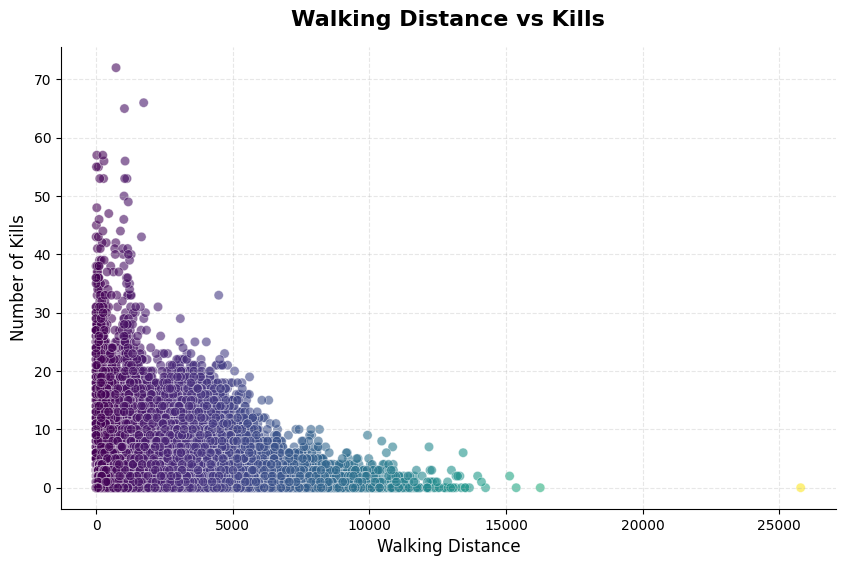

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="walkDistance",
    y="kills",
    data=data,
    alpha=0.6,                     # helps see through overlapping clusters
    edgecolor="white",             # thin borders keep points visually clear
    s=45,
    linewidth=0.4,
    hue="walkDistance",            # color highlights player movement intensity
    palette="viridis",             # smooth green-to-yellow gradient for readability
    legend=False                   # legend unnecessary since hue is continuous
)

# Add title and axis labels for clear communication
plt.title("Walking Distance vs Kills", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Walking Distance", fontsize=12)
plt.ylabel("Number of Kills", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)   # subtle grid for better interpretation
sns.despine()                               # cleaner style by removing extra borders

plt.show()

There is not much correlation between **walk distance** and **kills**. Players can move a lot without necessarily fighting, and aggressive players can secure kills even with low movement.

- Around **0–2000 walk distance**, some players reach more than 30 kills. This is often due to *hotdrops* — aggressive players landing in high-traffic areas where fights happen early. These players don’t focus on survival but on securing as many kills as possible in one location.
- At distances of **0–5000**, most players fall in the range of 0–20 kills. This represents the general population who move around and take a moderate number of fights.
- With very high distances (over **10,000**), kills are usually low (around 5 or less). These are likely players who prioritize survival and movement rather than heavy fighting — marathon-style players.
- There are also extreme outliers (50–70 kills), which are highly unrealistic and may represent cheaters or anomalies in the dataset.

**Conclusion:** Walk distance does not directly determine kills. Aggressive playstyle (hotdrops) can lead to high kills with little movement, while survival-focused players may cover long distances with few kills.

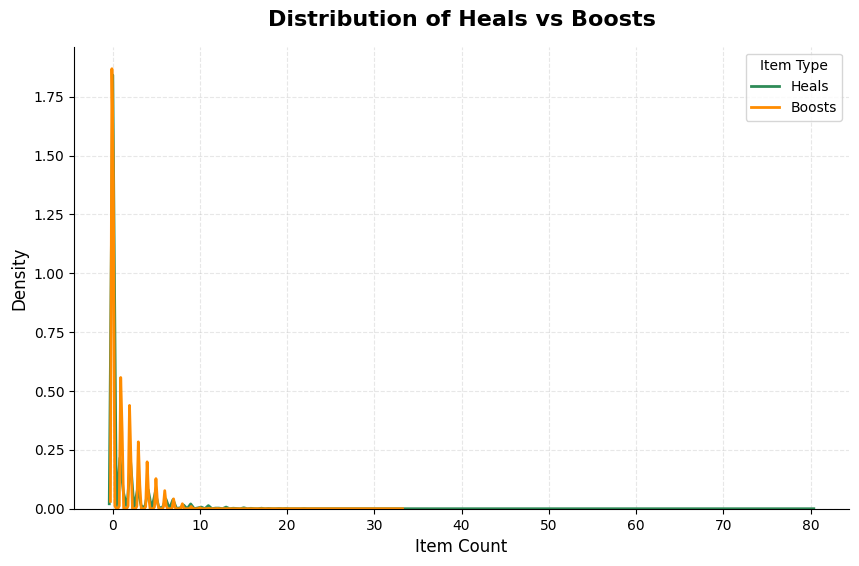

In [15]:
plt.figure(figsize=(10, 6))

# Compare distributions of heals and boosts using KDE lines
sns.kdeplot(data["heals"], label="Heals", color="seagreen", linewidth=2)
sns.kdeplot(data["boosts"], label="Boosts", color="darkorange", linewidth=2)

# Title and axis labels for clarity
plt.title("Distribution of Heals vs Boosts", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Item Count", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)   # subtle grid for readability
plt.legend(title="Item Type")               # legend to identify lines
sns.despine()                               # cleaner style

plt.show()

#### Interpretation: Heals vs Boosts

- **Heals** (bandages, first-aid kits, medkits) give instant recovery.
- **Boosts** (energy drinks, painkillers, adrenaline) recover health slowly and add speed.

**Patterns observed:**
- Most players use both in small to moderate amounts → *balanced playstyle*.
- More **heals than boosts** → players often in fights, taking direct damage, but not surviving long enough to rely on boosts.
- More **boosts than heals** → players focusing on survival or positioning (long rotations, camping, late-circle play).

**Outliers:**
- Very high values suggest extended matches (surviving until the final circle).
- Some extreme cases could also come from rare gameplay situations.

**Conclusion:**
Heals and boosts reflect different player styles:
- **Aggressive** → more heals.
- **Survival-focused** → more boosts.
- **Balanced** → moderate use of both.

### Multivariate Analysis

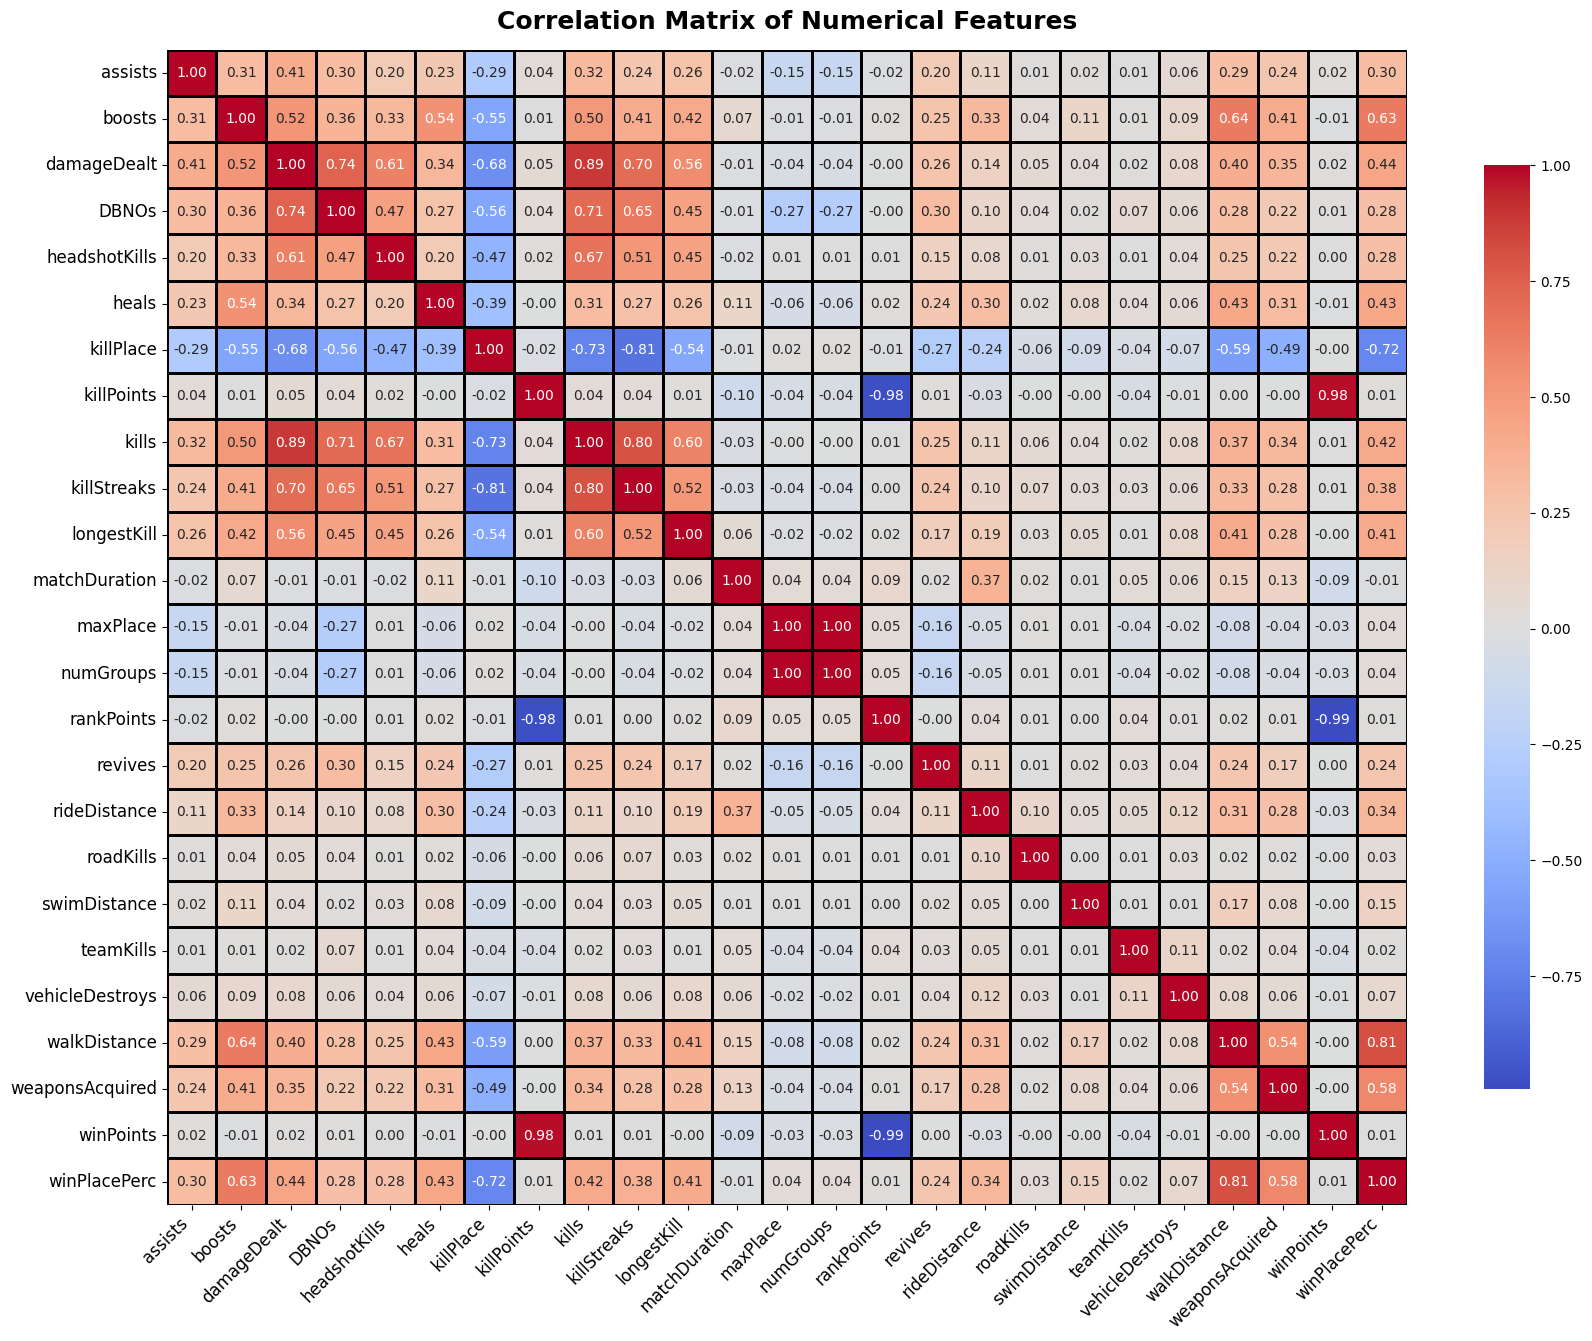

In [16]:
# Select numeric columns for correlation analysis
numerical_cols = data.select_dtypes(include=["int", "float"])

plt.figure(figsize=(20, 15))

sns.heatmap(
    numerical_cols.corr(),
    annot=True,                 # display correlation values inside cells
    fmt=".2f",                  # round to 2 decimals for clarity
    cmap="coolwarm",            # diverging colors: red = negative, blue = positive
    center=0,                   # ensures 0 correlation is the middle color
    linewidths=0.8,             # thin grid lines between cells
    linecolor="black",          # black grid for clean separation
    cbar_kws={"shrink": 0.8}    # shrink color bar for better balance
)

# Title and axis labels formatting
plt.title("Correlation Matrix of Numerical Features", fontsize=18, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=12)   # angled x-axis labels for readability
plt.yticks(rotation=0, fontsize=12)                # keep y-axis labels horizontal

plt.show()

The heatmap shows that several variables are highly correlated with each other:  

- **KillPoints and WinPoints** → very strong correlation (0.98).  
- **Kills and DamageDealt** → strong correlation (0.89).  
- **Kills and KillStreaks** → strong correlation (0.80).  
- **KillPlace and WinPlacePerc** → strong negative correlation (-0.72).  
- **RankPoints and WinPoints** → very strong negative correlation (-0.99).  

These high correlations indicate potential redundancy between variables, which can lead to multicollinearity in models such as linear regression.

In [17]:
data.drop(data[["Id", "groupId", "matchId", "rankPoints", "winPoints"]], axis = 1, inplace = True) 

#### Why these columns were dropped

- **Id, groupId, matchId** → These are only identifiers and do not carry any meaningful information about a player’s performance. They don’t help in predicting match outcomes, so they are unnecessary.

- **rankPoints and winPoints** → These features are not useful because:
  1. They show *very strong correlations* with other variables (e.g., `rankPoints` with `winPoints`, `killPoints` with `winPoints`). Keeping them can cause redundancy and multicollinearity in models.
  2. PUBG has **stopped using these metrics in its ranking system**. In the raw dataset, they often appear as **mostly zero or inconsistent values**, which means they don’t add reliable information for analysis.

By removing these columns, the dataset becomes cleaner and avoids unnecessary duplication of information.

---

### Note
Features are **not being dropped solely based on correlation**. A more detailed feature importance analysis will be performed later, and only then will additional features (if any) be removed.

## Data Preprocessing

### Data Cleaning

#### Checking for Duplicate Values 

In [18]:
data.duplicated().sum()

3266

In [19]:
# Dropping duplicate rows
data.drop_duplicates(inplace = True)

#### Checking for Null Values 

In [20]:
data.isnull().sum()

assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPlacePerc       1
dtype: int64

In [21]:
# Dropping rows having null values
data.dropna(subset=["killStreaks", "longestKill", "matchDuration", "matchType",
        "maxPlace", "numGroups", "revives", "rideDistance", "roadKills",
        "swimDistance", "teamKills", "vehicleDestroys", "walkDistance",
        "weaponsAcquired", "winPlacePerc"], inplace=True)

### Handling Outliers

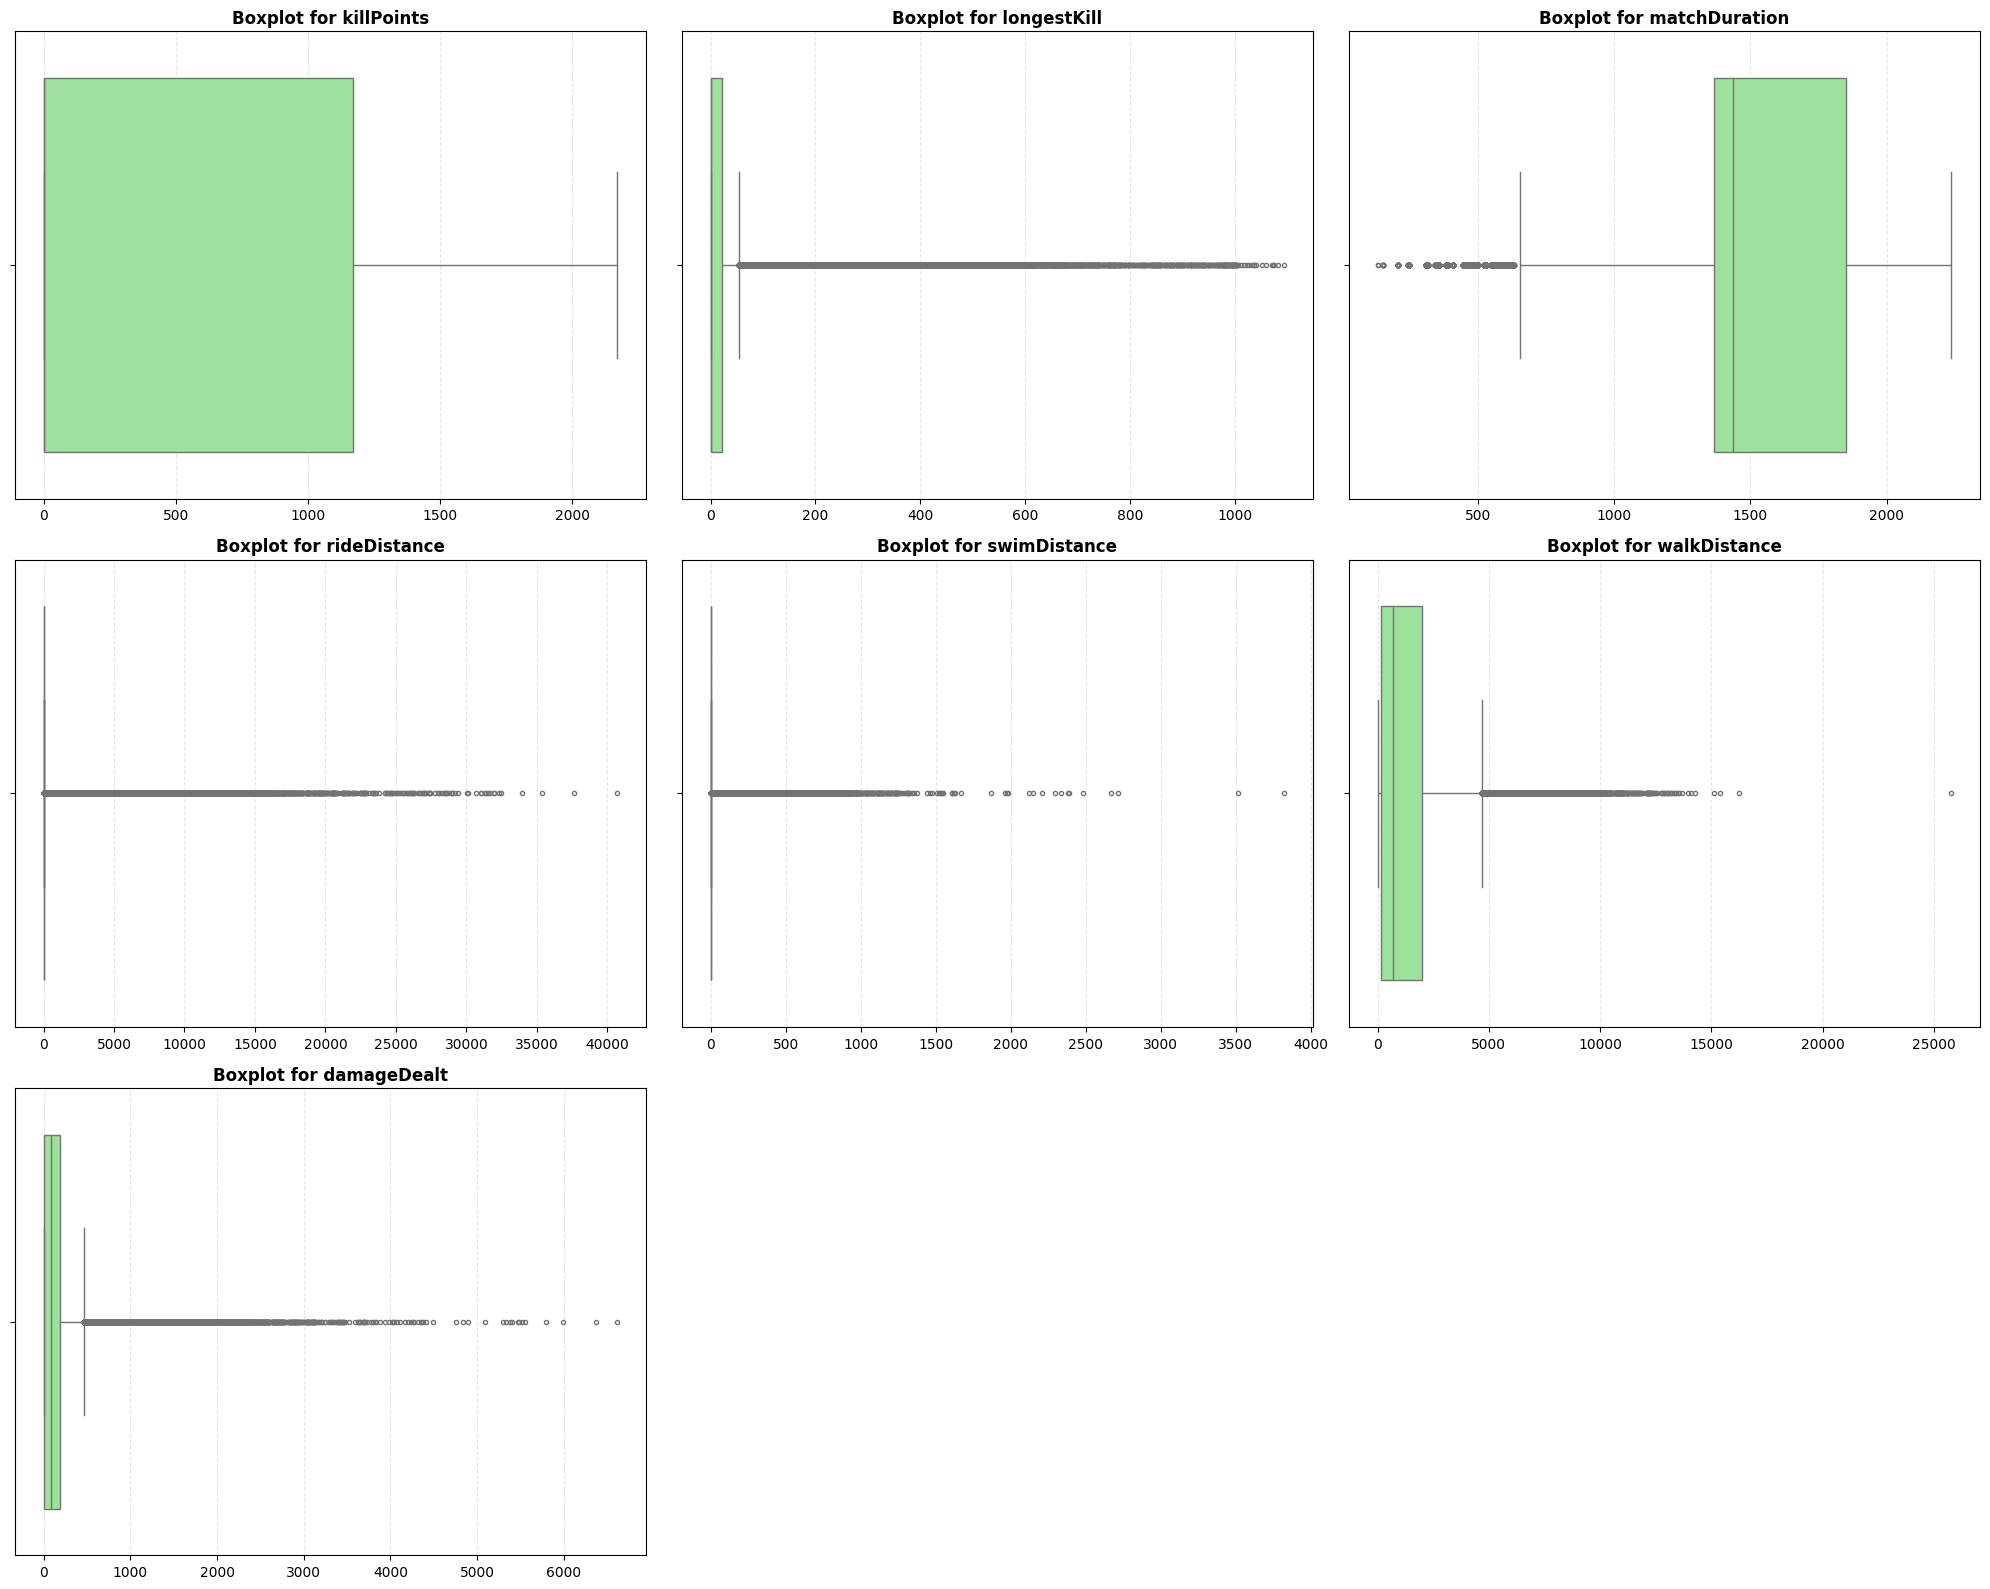

In [22]:
plt.figure(figsize=(20, 16))

# Key numerical features chosen for boxplot analysis
features = ["killPoints", "longestKill", "matchDuration",
            "rideDistance", "swimDistance", "walkDistance", "damageDealt"]

# Loop through features and plot boxplots
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)

    sns.boxplot(
        x=data[col],
        color="lightgreen",       # soft, consistent color theme
        fliersize=3,              # smaller points for outliers
        linewidth=1               # neat box edges
    )

    plt.title(f"Boxplot for {col}", fontsize=12, fontweight="bold", pad=6)
    plt.xlabel("")                                # no x-labels for a cleaner look
    plt.grid(axis="x", linestyle="--", alpha=0.3) # light grid along x-axis

plt.tight_layout()  # adjust spacing so plots don’t overlap
plt.show()

In [22]:
# Select continuous numerical columns for outlier treatment
con_cols = data[["killPoints", "longestKill", "matchDuration",
                 "rideDistance", "swimDistance", "walkDistance", "damageDealt"]]

# Apply IQR method on selected columns (excluding a few features where extreme values are natural)
for el in con_cols.drop(["killPoints", "rideDistance", "swimDistance", "damageDealt"], axis=1):
    Q1 = data[el].quantile(0.25)   # 25th percentile
    Q3 = data[el].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                  # Interquartile Range

    # Define acceptable range (Tukey’s rule: 1.5 * IQR)
    lower_boundary = Q1 - 1.5 * IQR
    upper_boundary = Q3 + 1.5 * IQR

    # Replace outliers with median to reduce distortion while preserving distribution
    data.loc[(data[el] < lower_boundary) | (data[el] > upper_boundary), el] = data[el].median() 

In [23]:
# Remove extreme outliers in damageDealt (players with > 3500 damage are unrealistic cases)
data.drop(data.loc[data["damageDealt"] > 3500].index, inplace=True)

In [24]:
# Remove unrealistic outliers in rideDistance (values > 20,000 are not practical in normal matches)
data.drop(data.loc[data["rideDistance"] > 20000].index, inplace=True)

In [25]:
# Remove unrealistic outliers in swimDistance (values > 1200 are rare/unrealistic in typical matches)
data.drop(data.loc[data["swimDistance"] > 1200].index, inplace=True)

## Feature Engineering (New Features) 

In [26]:
# 1. Total Distance
data["totalDistance"] = data["walkDistance"] + data["rideDistance"] + data["swimDistance"]

**Total Distance**: Represents the overall mobility of a player by combining walking, riding, and swimming distances. Players who travel more usually survive longer and have better looting opportunities.

In [27]:
# 2. Headshot Ratio (headshot kills / kills)
data["headshotRatio"] = np.where(data["kills"] > 0, data["headshotKills"] / data["kills"], 0)

**Headshot Ratio**: Shows the share of kills made via headshots. A higher ratio indicates better aiming skills and combat precision.

In [28]:
# 3. Aggression Index ((kills + DBNOs) / matchDuration)
data["aggressionIndex"] = np.where(data["matchDuration"] > 0, (data["kills"] + data["DBNOs"]) / data["matchDuration"], 0)

**Aggression Index**: Measures how aggressive a player is by calculating engagements (kills + knockdowns) per unit of survival time. Helps differentiate rush players from campers.

In [29]:
# 4. Damage Per Kill (damageDealt / kills)
data["damagePerKill"] = np.where(data["kills"] > 0, data["damageDealt"] / data["kills"], 0)

**Damage Per Kill**: Reflects combat efficiency by showing how much damage a player needs on average to secure a kill. Lower values mean efficient finishing, while higher values suggest wasted bullets or unconfirmed kills.

In [30]:
# 6. Team Contribution (assists + revives)
data["teamContribution"] = data["assists"] + data["revives"]

**Team Contribution**: Captures the supportive role of a player through assists and revives. It helps identify team-oriented players beyond just kill counts.

In [31]:
data.head()  # Showing first few rows for a quick glance at structure

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPlacePerc,totalDistance,headshotRatio,aggressionIndex,damagePerKill,teamContribution
0,0,0,0.00,0,0,0,60,1241,0,0,0.00,1306,squad-fpp,28,26,0,0.00,0,0.00,0,0,244.80,1,0.44,244.80,0.00,0.00,0.00,0
1,0,0,91.47,0,0,0,57,0,0,0,0.00,1777,squad-fpp,26,25,0,0.00,0,11.04,0,0,1434.00,5,0.64,1445.04,0.00,0.00,0.00,0
2,1,0,68.00,0,0,0,47,0,0,0,0.00,1318,duo,50,47,0,0.00,0,0.00,0,0,161.80,2,0.78,161.80,0.00,0.00,0.00,1
3,0,0,32.90,0,0,0,75,0,0,0,0.00,1436,squad-fpp,31,30,0,0.00,0,0.00,0,0,202.70,3,0.17,202.70,0.00,0.00,0.00,0
4,0,0,100.00,0,0,0,45,0,1,1,0.00,1424,solo-fpp,97,95,0,0.00,0,0.00,0,0,49.75,2,0.19,49.75,0.00,0.00,100.00,0


## Encoding Categorical Variables 

In [32]:
from sklearn.preprocessing import LabelEncoder # Importing required library/module

In [33]:
# Label-encoding smoker (binary) to 0/1 for downstream models
label_enc = LabelEncoder()
data["matchType"] = label_enc.fit_transform(data["matchType"])

## Spliting data into training and testing

In [34]:
# Split the dataset into features (x) and target variable (y).
x = data.drop("winPlacePerc", axis = 1) # x contains all the columns except 'winPlacePerc' (the target variable).
y = data["winPlacePerc"] # y contains only the 'winPlacePerc' column, which is the target variable that the model will predict.

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.25)
# x_train and y_train will be used to train the model, while x_test and y_test will be used for evaluation.
# The test size is set to 25% of the data (test_size = 0.25), meaning 75% will be used for training.
# random_state = 42 ensures that the split is reproducible. Using the same random_state will give the same split every time.

## Scaling

In [36]:
from sklearn.preprocessing import MinMaxScaler # Importing required library/module

In [37]:
 # Selecting continuous features for scaling
con_cols = ["killPoints", "longestKill", "matchDuration", "rideDistance", "swimDistance", "walkDistance", "damageDealt"]

# Scaling/normalizing features
minmax_scaler = MinMaxScaler()
x_train[con_cols] = minmax_scaler.fit_transform(x_train[con_cols])
x_test[con_cols] = minmax_scaler.transform(x_test[con_cols])

In [38]:
x_train

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,longestKill,matchDuration,matchType,maxPlace,numGroups,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,totalDistance,headshotRatio,aggressionIndex,damagePerKill,teamContribution
515353,0,0,0.01,0,0,0,96,0.49,0,0,0.00,0.80,15,28,28,0,0.00,0,0.00,0,0,0.01,0,44.46,0.00,0.00,0.00,0
3669819,0,0,0.03,0,0,0,40,0.00,1,1,0.25,0.82,12,95,94,0,0.00,0,0.00,0,0,0.08,4,379.50,0.00,0.00,100.00,0
557377,2,0,0.03,1,2,0,18,0.50,2,2,0.44,0.46,3,48,47,0,0.00,0,0.00,0,0,0.27,5,1263.00,1.00,0.00,57.25,2
1322006,0,0,0.04,0,1,0,38,0.00,1,1,0.66,0.77,13,96,92,0,0.00,0,0.00,0,0,0.06,2,271.20,1.00,0.00,150.30,0
1320215,0,1,0.03,1,0,1,33,0.00,1,1,0.50,0.71,15,29,28,0,0.00,0,0.00,0,0,0.16,5,769.00,0.00,0.00,100.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136468,0,0,0.03,1,0,0,91,0.00,0,0,0.00,0.42,15,29,29,0,0.00,0,0.00,0,0,0.02,3,116.80,0.00,0.00,0.00,0
1570685,0,4,0.14,0,3,2,2,0.00,5,1,0.42,0.50,13,95,93,0,0.00,0,0.00,0,0,0.38,4,1810.00,0.60,0.00,95.76,0
2235699,0,1,0.05,1,1,1,14,0.00,2,1,0.34,0.76,3,46,44,0,0.08,0,0.00,0,0,0.68,8,4836.00,0.50,0.00,79.70,0
4307933,0,1,0.04,1,0,3,20,0.60,1,1,0.03,0.44,14,26,24,0,0.00,0,0.00,0,0,0.60,3,2831.00,0.00,0.00,149.40,0


## Model Creation and Evaluation

In [39]:
# Importing different regression models to experiment with multiple algorithms

# LinearRegression: A simple model that assumes a linear relationship between features and the target.
from sklearn.linear_model import LinearRegression

# RandomForestRegressor: An ensemble model that builds many decision trees and averages predictions to improve accuracy and reduce overfitting.
from sklearn.ensemble import RandomForestRegressor

# XGBRegressor: A gradient boosting algorithm optimized for speed and performance, often used in competitive ML tasks.
from xgboost import XGBRegressor

# LGBMRegressor: A gradient boosting algorithm similar to XGBoost but faster on large datasets due to optimized histogram-based learning.
from lightgbm import LGBMRegressor

# MLPRegressor: A neural network-based regressor that can capture complex non-linear relationships in data.
from sklearn.neural_network import MLPRegressor

In [40]:
# Importing regression metrics from sklearn to evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Feature Importance Analysis 

-- LightGBM Regressor --
R2_Score: 0.9264330910372738
MAE: 0.0597595365813954


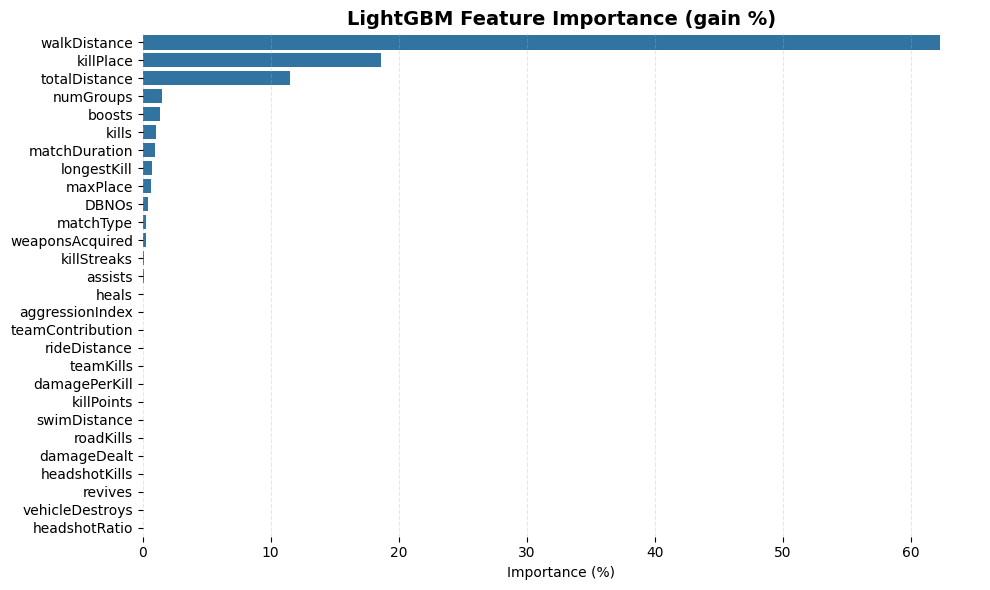


Feature importances (by gain %):


,Feature,Importance_%
0,walkDistance,62.31
1,killPlace,18.63
2,totalDistance,11.51
3,numGroups,1.47
4,boosts,1.36
5,kills,1.01
6,matchDuration,0.96
7,longestKill,0.71
8,maxPlace,0.69
9,DBNOs,0.43


In [43]:
# Train LightGBM and report basic metrics + feature importance (gain)
lgbm = LGBMRegressor(random_state=42, verbose = 0)
lgbm.fit(x_train, y_train)

y_pred = lgbm.predict(x_test)

print("-- LightGBM Regressor --")
print("R2_Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Get the trained booster and extract gain-based importances
booster = lgbm.booster_
importance_gain = booster.feature_importance(importance_type="gain")

# Convert to percentage so it's easier to compare
importance_percent = 100 * importance_gain / importance_gain.sum()

feature_imp_lgbm = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance_%": importance_percent
}).sort_values(by="Importance_%", ascending=False).reset_index(drop=True)

# Quick bar plot for the report
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance_%", y="Feature", data=feature_imp_lgbm)
plt.title("LightGBM Feature Importance (gain %)", fontsize=14, fontweight="bold")
plt.xlabel("Importance (%)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Show the table (nice and readable)
print("\nFeature importances (by gain %):")
feature_imp_lgbm

-- XGBoost Regressor --
R2_Score: 0.9288899278895371
MAE: 0.05854485959663593


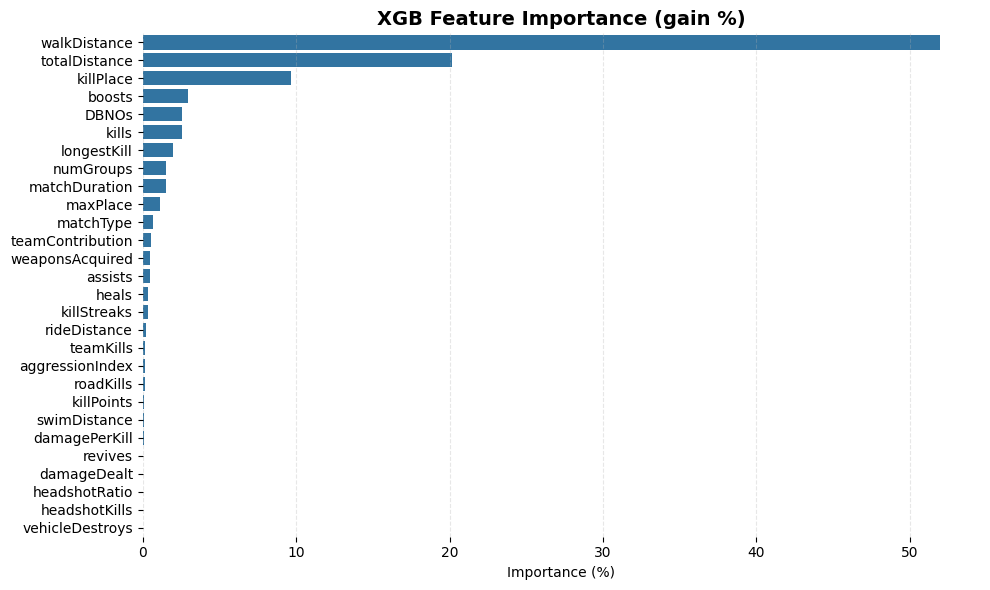


Feature importances (by gain %):


,Feature,Importance_%
0,walkDistance,51.97
1,totalDistance,20.19
2,killPlace,9.67
3,boosts,2.97
4,DBNOs,2.54
5,kills,2.53
6,longestKill,1.97
7,numGroups,1.54
8,matchDuration,1.50
9,maxPlace,1.11


In [44]:
# Train XGBoost Regressor
xgb = XGBRegressor(random_state=42)
xgb.fit(x_train, y_train)

# Predictions & evaluation metrics
y_pred = xgb.predict(x_test)
print("-- XGBoost Regressor --")
print("R2_Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Extract gain-based feature importance from the trained booster
booster = xgb.get_booster()
gain_dict = booster.get_score(importance_type="gain")  # dict: {feature_name: gain_value}

# Convert to Series and align with all training columns (missing = 0 importance)
gains = pd.Series(gain_dict, dtype=float)
gains = gains.reindex(x_train.columns, fill_value=0.0)

# Normalize to percentages (if all gains are zero, keep 0s to avoid error)
total_gain = gains.sum()
importance_percent = (100 * gains / total_gain) if total_gain > 0 else pd.Series(0.0, index=gains.index)

# Final sorted dataframe of feature importances
feature_imp_xgb = (
    pd.DataFrame({"Feature": x_train.columns, "Importance_%": importance_percent.values})
      .sort_values(by="Importance_%", ascending=False)
      .reset_index(drop=True)
)

# Quick bar plot for the report
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance_%", y="Feature", data=feature_imp_xgb)
plt.title("XGB Feature Importance (gain %)", fontsize=14, fontweight="bold")
plt.xlabel("Importance (%)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Show the table (nice and readable)
print("\nFeature importances (by gain %):")
feature_imp_xgb

In [41]:
# Columns to drop based on feature importance analysis (low/redundant contribution)
cols_to_drop = [
    "vehicleDestroys", "headshotKills", "headshotRatio",
    "damageDealt", "revives", "damagePerKill",
    "swimDistance", "killPoints", "roadKills"
]

# Remove selected columns from train and test sets
x_train.drop(cols_to_drop, axis=1, inplace=True)
x_test.drop(cols_to_drop, axis=1, inplace=True) 

**Before training the final model, I wanted to check which features are actually the most useful.  
For this, I used **LightGBM** and **XGBoost**, since both provide built-in feature importance.  
This helps in understanding which features strongly impact the predictions and which ones contribute very little.  
The results from this step will guide me in deciding if I should drop less important features and keep the model more focused.** 

### Training Model for Prediction 

In [42]:
# Function to evaluate models on training and testing sets
def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Fit (train) the model on training data
    model.fit(x_train, y_train)

    # Predict on training data
    y_train_pred = model.predict(x_train)

    # Predict on testing data
    y_test_pred = model.predict(x_test)

    # Calculate R² (coefficient of determination) for training set
    r2_train = r2_score(y_train, y_train_pred)

    # Calculate R² for testing set
    r2_test = r2_score(y_test, y_test_pred)

    # Calculate error metrics on test set
    mae = mean_absolute_error(y_test, y_test_pred)        # Mean Absolute Error
    mse = mean_squared_error(y_test, y_test_pred)         # Mean Squared Error
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))  # Root Mean Squared Error

    # Return all metrics
    return r2_train, r2_test, mae, mse, rmse


# Dictionary containing different regression models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state = 42),
    "XGBoost": XGBRegressor(random_state = 42, verbosity = 0),
    "LightGBM": LGBMRegressor(random_state = 42, verbosity = 0),
    "MLP" : MLPRegressor(random_state = 42)
}


# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Get evaluation metrics
    r2_train, r2_test, mae, mse, rmse = evaluate_model(model, x_train, y_train, x_test, y_test)

    # Save results in dictionary
    results[name] = {
        "R2_Score_Train": r2_train,
        "R2_Score_Test": r2_test,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }


# Convert results dictionary into a DataFrame for easy visualization
results_df = pd.DataFrame(results).T  # .T transposes rows ↔ columns
results_df

,R2_Score_Train,R2_Score_Test,MAE,MSE,RMSE
Linear Regression,0.83,0.83,0.09,0.02,0.13
Random Forest,0.99,0.93,0.06,0.01,0.08
XGBoost,0.93,0.93,0.06,0.01,0.08
LightGBM,0.93,0.93,0.06,0.01,0.08
MLP,0.89,0.89,0.07,0.01,0.10


## Model Comparison Report

After training multiple models on the dataset, here’s a summary of their performance:

- **Linear Regression** gave a baseline R² of 0.83. It performs decently but clearly lags behind more advanced models. The higher errors (MAE: 0.09, RMSE: 0.13) suggest that linear assumptions were too simple for this problem.  

- **Random Forest** performed very strongly on training data (R²: 0.99) but dropped to 0.93 on the test set, showing signs of slight overfitting. While the error values are low, the large training–test gap means it may not generalize as smoothly.  

- **XGBoost** and **LightGBM** both stood out as the most balanced models. They achieved R² of 0.93 on both training and test data, with very low error (MAE: 0.06, RMSE: 0.08). These results indicate good generalization without overfitting, making them reliable choices.  

- **MLP (Neural Network)** did better than Linear Regression (R²: 0.89), but it could not outperform tree-based methods. While not poor, it doesn’t offer clear advantages over boosting models.  

### Final Thoughts
The results show that ensemble methods, especially **XGBoost and LightGBM**, are the best fit for this dataset. Both models strike a solid balance between accuracy and generalization. Random Forest is slightly less stable due to overfitting, and simpler models (Linear Regression, MLP) do not match the performance of boosting methods.

✅ **Best Choice:** XGBoost or LightGBM (depending on speed/deployment preference). 

## Challenges Faced Report 

During the analysis, a few challenges came up that made the process tricky and required extra attention:

### 1. Large Dataset Size  
The dataset had more than **4.4 million rows**, which made it heavy to handle. Some operations like grouping, plotting, or model training slowed down the system and needed optimization.

### 2. Outliers Everywhere  
Several columns had extreme and unrealistic values (for example, 70+ kills, 200+ weapons picked, or ride distances over 400,000). These outliers made the statistics look misleading and forced us to carefully decide whether to remove or cap them.

### 3. Too Many Zeros  
For many features (kills, headshots, DBNOs, swimming, vehicle destroys), most players had a value of **zero**. This imbalance made it harder to spot useful patterns and reduced the predictive strength of those features.

### 4. Unreliable Columns  
Some columns like **killPoints, winPoints, and rankPoints** were either outdated or not consistently recorded. Depending on them could give the wrong picture, so they had to be filtered or dropped.

### 5. Different Match Types  
The dataset included **16 different match formats** (solo, duo, squad, FPP, TPP, etc.). Each format had its own style of gameplay, which made comparisons challenging and required extra steps for fair analysis.

### 6. Heavy Computation for Models  
Training models on such a big dataset was resource-intensive. Hyperparameter tuning in particular was difficult because of the time and memory it consumed, so in some cases, sampling or reducing features became necessary.

### 7. Cleaning and Feature Selection  
Some columns, like unique identifiers (**Id, groupId, matchId**), didn’t add value for analysis but increased noise. Deciding what to drop or keep was an important part of the cleaning process. Handling missing values and striking a balance between **data quality** and **data quantity** also needed careful thought. 